##기상 관련 공공 데이터를 처리해 보자.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt   # 시각화를 위한 라이브러리

# 레티나 디스플레이를 지원하도록 해서 한글이 흐릿하게 보이는 현상 개선
%config InlineBackend.figure_format = 'retina'

#한글 나눔 폰트 사용설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

 # 해당 폰트를 기본 폰트가 되도록 설정
import matplotlib.font_manager as fm
fontpath = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
font = fm.FontProperties(fname=fontpath, size=9)
plt.rc('font', family='NanumBarunGothic')

#실행->런타임 다시시작->재실행 해야함

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 16 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

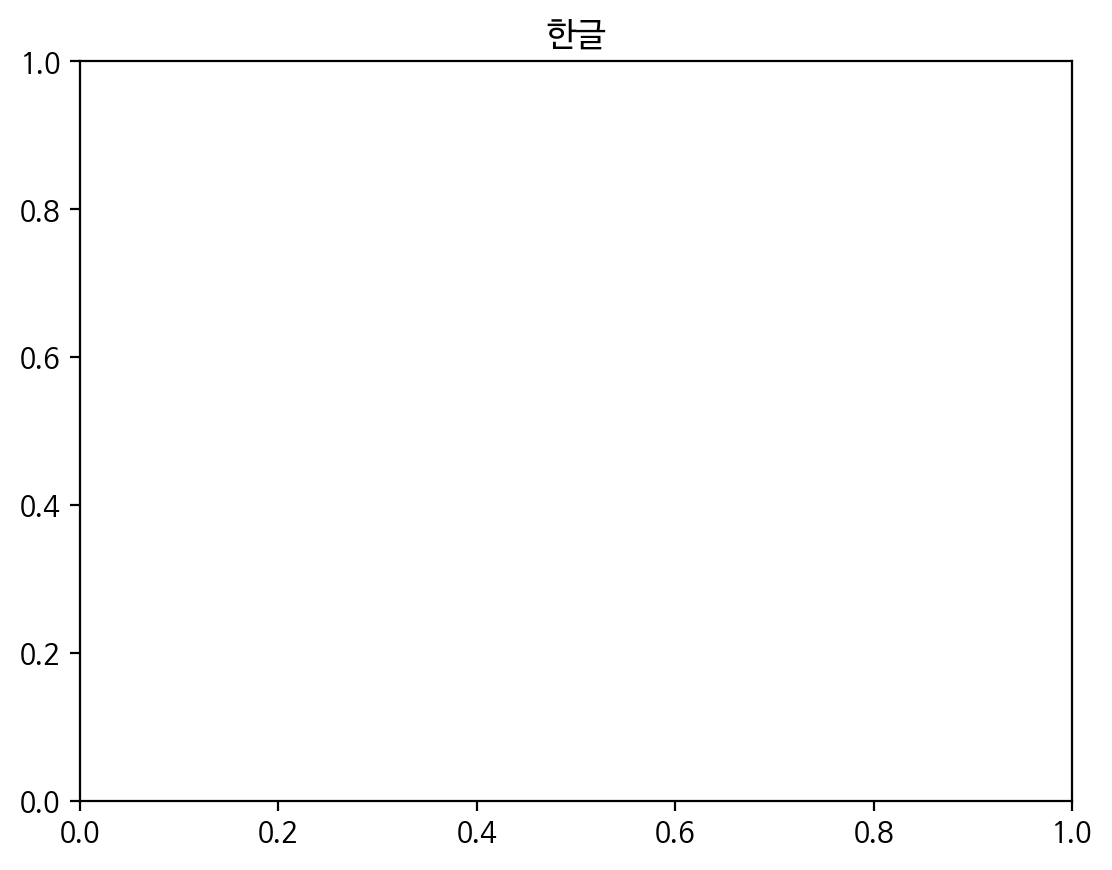

In [2]:
plt.title('한글')
plt.show()

##1. 표 데이터 처리하기
##### ① pandas 라이브러리 사용하기
#####코랩에서 pandas를 사용하려면 항상 코드의 시작 부분에서 라이브러리를 불러와야 한다. pandas의 이름을 pd라고 정해 보자.

In [5]:
#pandas 라이브러리의 별칭(alias) pd로 정하기
import pandas as pd

② 코랩에서 파일 업로드하기

###### 기상 자료 개방 포털에서 수집했던 데이터를 코랩에서 업로드해 보자

In [6]:
#코랩에서 사용할 파일을 업로드하기
from google.colab import files
myfile = files.upload()

Saving seoul_temp.csv to seoul_temp (2).csv


③ 데이터 프레임에 저장하기
#####csv 파일을 읽어 올 때는 파일 경로와 인코딩 방식 등을 입력한 read_csv( ) 함수를 사용해 보자.

In [7]:
# cp949 방식으로 인코딩된 seoul_temp.csv 파일을 불러와서
# df라는 이름의 데이터 프레임에 저장하기
df=pd.read_csv('seoul_temp.csv',encoding='cp949')

In [8]:
#df 데이터 프레임에 저장된 내용 확인하기
df

,년,지점,평균기온,최저기온,최고기온
0,1907,108,NaN,-20.1,25.4
1,1908,108,10.4,-15.8,33.6
2,1909,108,10.6,-14.6,35.6
3,1910,108,10.3,-19.9,33.3
4,1911,108,10.6,-21.5,34.5
...,...,...,...,...,...
107,2014,108,13.4,-13.2,35.8
108,2015,108,13.6,-13.0,36.0
109,2016,108,13.6,-18.0,36.6
110,2017,108,13.0,-12.6,35.4


##2. 데이터 살펴보기
#####① 데이터 일부 살펴보기
df.head( )를 사용하여 데이터의 앞부분 5행을 살펴보자.

In [9]:
# 데이터의 앞부분(5개)만 살펴보기
df.head()

# ‌df.head(3): 괄호 안에 넣은 숫자의 행만큼 데이터를 볼 수 있다.
# ( ) 안에 숫자를 생략하면 기본으로 5행을 지정한다.

,년,지점,평균기온,최저기온,최고기온
0,1907,108,NaN,-20.1,25.4
1,1908,108,10.4,-15.8,33.6
2,1909,108,10.6,-14.6,35.6
3,1910,108,10.3,-19.9,33.3
4,1911,108,10.6,-21.5,34.5


df의 내용 중 데이터 앞부분 5행이 출력된다. 첫 번째 행의 ‘평균기온’ 값이 비어 있는 것을 확인할 수 있다

② 요약된 데이터의 정보 살펴보기
##### df.describe( )를 사용해서 데이터의 전체적인 통계적 특성을 살펴보자.

In [10]:
#데이터의 전체적인 통계적 특성 살펴보기
df.describe( )

,년,지점,평균기온,최저기온,최고기온
count,112.000000,112.0,107.000000,110.000000,110.000000
mean,1962.500000,108.0,11.674766,-16.511818,34.780909
std,32.475632,0.0,0.969740,3.083211,2.517553
min,1907.000000,108.0,9.600000,-23.100000,16.200000
25%,1934.750000,108.0,10.900000,-18.600000,33.925000
50%,1962.500000,108.0,11.600000,-16.850000,35.050000
75%,1990.250000,108.0,12.400000,-14.100000,36.000000
max,2018.000000,108.0,13.800000,-8.600000,39.600000


실행 결과를 통해 특성별 값의 개수(count), 평균(mean), 표준편차(std), 최솟값(min), 최댓값(max) 등을 알 수 있다.

## 3. 데이터 전처리하기
① 빈 값 확인하기
##### df.isnull( ).sum( )을 사용해서 전체 데이터 중 어떤 열에 빈 값이 얼마나 존재하는지 확인해 보자

In [11]:
# 열(column)마다 빈 값이 있는지 확인하기
df.isnull( ).sum( )

년       0
지점      0
평균기온    5
최저기온    2
최고기온    2
dtype: int64

실행 결과를 확인해 보면 ‘평균기온’은 5개, ‘최저기온’과 ‘최고기온’은 각각 2개의
데이터가 비어 있다는 것을 알 수 있다.

‌df.isnull( ).sum( ): 데이터가 많으면 한눈에 보이지 않기 때문에
sum( ) 메소드를 추가해서 어떤 열에 빈 값이 몇 개나 존재하는
지 확인할 수 있다.

② 빈 값 처리하기
##### df.fillna(method = ‘bfill’)을 사용해서 빈 값을 다음 값으로 채워 보자.
결측값 변경방식:
- bfill 결측값을 바로 아래 값과 동일하게 변경
- ffill 결측값을 바로 위값과 동일하게 변경

In [12]:
# 원래 데이터 프레임에 빈 값을 다음 값으로 채우기
# 별도의 데이터 프레임에 저장하지 않고 원래의 데이터 프레임의
# 값을 바꾸고 싶다면 inplace라는 속성을 True로 설정한다.
df.fillna(method='bfill', inplace=True)
df

,년,지점,평균기온,최저기온,최고기온
0,1907,108,10.4,-20.1,25.4
1,1908,108,10.4,-15.8,33.6
2,1909,108,10.6,-14.6,35.6
3,1910,108,10.3,-19.9,33.3
4,1911,108,10.6,-21.5,34.5
...,...,...,...,...,...
107,2014,108,13.4,-13.2,35.8
108,2015,108,13.6,-13.0,36.0
109,2016,108,13.6,-18.0,36.6
110,2017,108,13.0,-12.6,35.4


원래 비어 있던 값이 다음 값과 같은 값으로 채워진 것을 확인할 수 있다.

df.fillna(method = 'bfill', inplace = True): inplace 속성을
True로 설정하면 원본 데이터 프레임(df)의 내용이 바뀌게 된다.

## 4 데이터 선택하기
##### ① 원하는 열 선택하기
*  특정한 속성의 데이터를 확인하기 위해 특정 열을 선택해 보자.

In [13]:
#'년' 열만 선택하기
# 특정한 속성의 데이터를 확인하려면 특정 열을 선택해야 한다.
#‌ ‌df['년'].head( ): 데이터 프레임 이름 뒤에 대괄호 [ ]를 추가하고
# 대괄호 안에 열의 이름은 작은따옴표(' ')로 감싼다.

df['년'].head()

0    1907
1    1908
2    1909
3    1910
4    1911
Name: 년, dtype: int64

*   2개 이상의 열을 선택하기 위해 열 리스트를 작성하는 방법을 알아보자.

In [14]:
#'년', '평균기온' 열 선택하기
# 두 개 이상의 열('년'과 '평균기온')을 선택할 때는 열 리스트를 작성한다.
# df[['년', '평균기온']]: 리스트는 [데이터1, 데이터2, 데이터3,...]의 형태로 구성된다.
# a = ['사과', '귤', '참외', '수박']

df[['년', '평균기온']].head()

,년,평균기온
0,1907,10.4
1,1908,10.4
2,1909,10.6
3,1910,10.3
4,1911,10.6


‘년’, ‘평균기온’에 해당하는 열의 첫 5행이 출력된 것을 확인할 수 있다.

#####② 원하는 행 선택하기
데이터 프레임의 슬라이싱 기능을 활용하여 원하는 행을 선택해 보자.

In [15]:
# 행 인덱스 기준으로 선택하기

df[43:47]

,년,지점,평균기온,최저기온,최고기온
43,1950,108,11.4,-18.0,36.9
44,1951,108,11.4,-9.2,16.2
45,1952,108,11.4,-9.2,16.2
46,1953,108,11.4,-9.2,16.2


#####③ 조건에 따라 선택하기
조건을 주어 선택한 열 데이터 중 원하는 조건에 일치하는지 확인해 보자

In [16]:
#여러 조건에 따라 선택하기
#2000년 이후이고 평균기온이 13을 넘는 행 출력

df[(df['년']>2000) &  (df['평균기온']>13)]

,년,지점,평균기온,최저기온,최고기온
97,2004,108,13.3,-16.7,36.2
100,2007,108,13.3,-8.6,33.2
107,2014,108,13.4,-13.2,35.8
108,2015,108,13.6,-13.0,36.0
109,2016,108,13.6,-18.0,36.6


##5. 서울의 평균 기온 데이터 그래프로 표현하기

① 서울시 평균 기온 데이터 선그래프로 표현하기

1907년부터 2018년까지 서울 관측소에서 측정한 연평균기온을 선그래프로 나타내 보자.

In [18]:
df2=pd.read_csv('seoul_temp.csv', encoding='cp949')

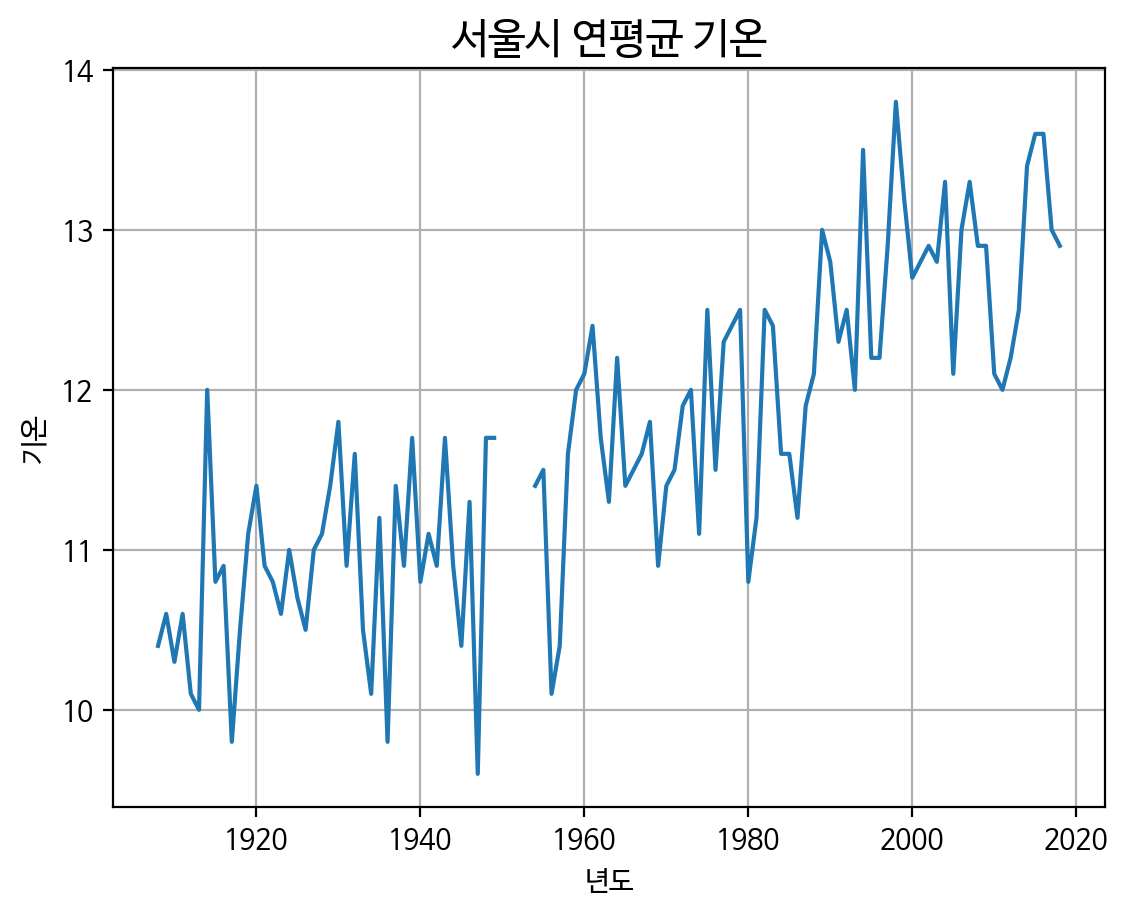

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#서울시 연평균기온 선그래프 그리기
#글자 크기는 15로 그래프의 제목을 설정한다.
plt.title('서울시 연평균 기온', size=15)
# x축 제목을 설정한다.
plt.xlabel('년도')
# y축 제목을 설정한다.
plt.ylabel('기온')
#그래프의 격자를 추가한다.
plt.grid()
#선그래프 그리기
plt.plot(df2['년'], df2['평균기온'])
plt.show()

실행결과 그래프에서 결측치를 찾아보자.

## 6. 기온 데이터를 이용한 문제 해결하기

① 결측치 데이터가 있는 해를 찾아보기

위의 그래프에서 평균 기온이 없는 연도를 찾아보자.

In [24]:
#1946~1954년까지 연도별 기온값 추출하기 코드 이해하기
df2[(df2['년']>1945) & (df2['년']<1955) ]
#1945년 초과 1955년 미만인 연도의 데이터를 출력한다.

,년,지점,평균기온,최저기온,최고기온
39,1946,108,11.3,-17.0,36.7
40,1947,108,9.6,-17.3,33.5
41,1948,108,11.7,-18.0,34.4
42,1949,108,11.7,-14.9,37.7
43,1950,108,NaN,-18.0,36.9
44,1951,108,NaN,NaN,NaN
45,1952,108,NaN,NaN,NaN
46,1953,108,NaN,-9.2,16.2
47,1954,108,11.4,-13.9,34.3


② 연도별 최고 기온, 평균 기온, 최저 기온을 하나의 그래프로 표현하기

1907년부터 2020년까지 서울 관측소에서 측정한 최고 기온, 평균 기온, 최저 기온을 선그래프로 나타내 보자.

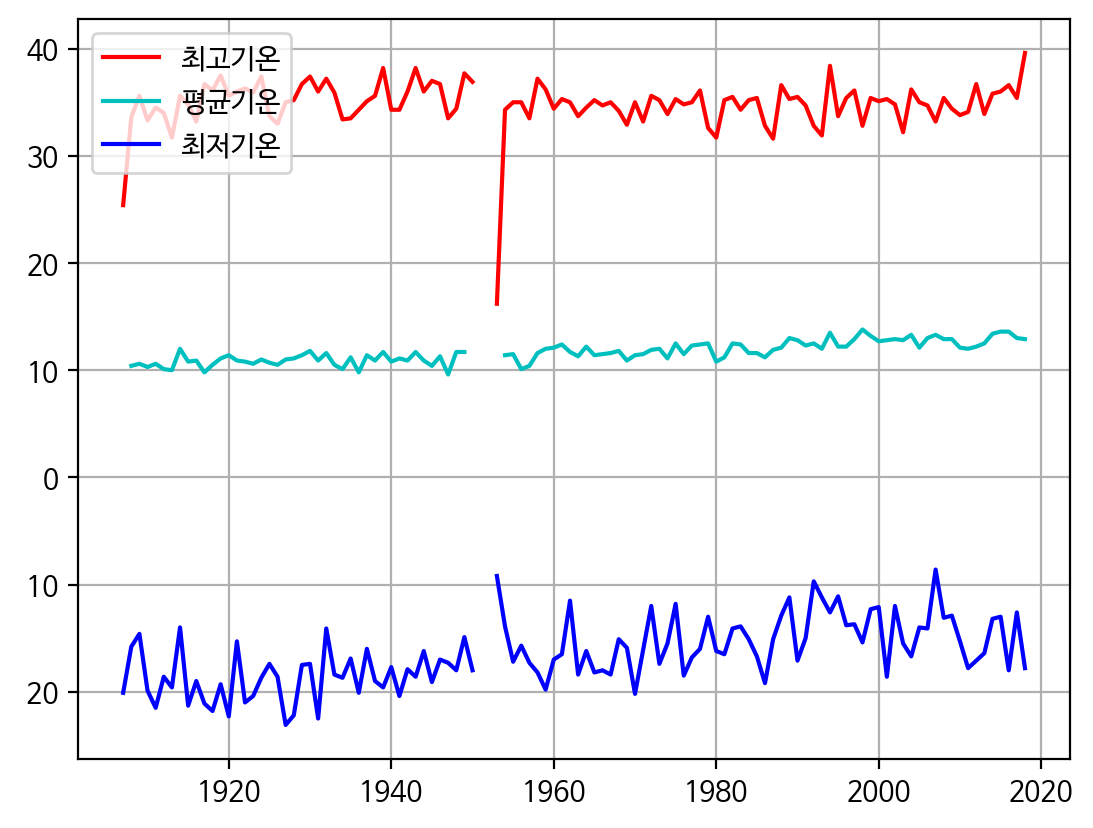

In [34]:
#연도별 최고/평균/최저기온 그래프로 그리기 코드 이해하기

#해당 연별 최고 기온은 빨간색으로 그리고,'최고기온’으로 레이블을 추가
plt.plot(df2['년'],df2['최고기온'],'r',label='최고기온')

#해당 연별 평균 기온은 청록색으로 그리고,‘평균기온’으로 레이블을 추가
plt.plot(df2['년'],df2['평균기온'],'c',label='평균기온')

#해당 연별 최저 기온은 파란색으로 그리고,‘최저기온’으로 레이블을 추가
plt.plot(df2['년'],df2['최저기온'],'b',label='최저기온')

#그리드 추가하기
plt.grid()

#범례 추가하기
plt.legend()

plt.show()

③ 2000년 이후의 연도별 최고 기온, 평균 기온, 최저 기온을 하나의 그래프로 표현하기

기온 데이터에서 2000년 이후의 데이터만 추출해서 최근의 기온 변화를 선그래프와 막대그래프로 각각 나타내 보자.

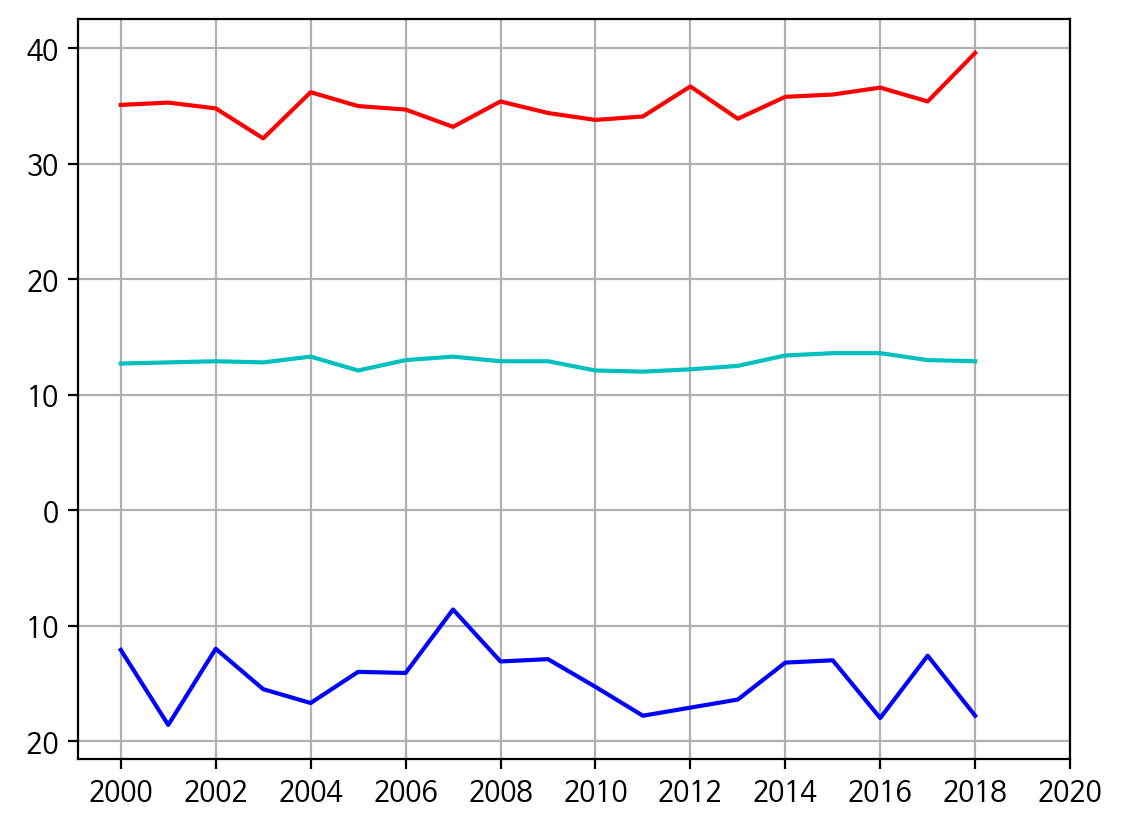

In [47]:
#2000년 이후의 최고/평균/최저기온 선그래프로 그리기 코드 이해하기

#2000년 이상인 데이터만 추출하여 df3에 저장한다.
df3=df2[df2['년']>=2000]

# 해당 연별 최고 기온은 빨간색으로 선그래프를 그린다.
plt.plot(df3['년'],df3['최고기온'],'r')

# 해당 연별 평균 기온은 청록색으로 선그래프를 그린다.
plt.plot(df3['년'],df3['평균기온'],'c')

# 해당 연별 최저 기온은 파란색으로 선그래프를 그린다.
plt.plot(df3['년'],df3['최저기온'],'b')

#그리드 추가하기
plt.grid()

#x축의 좌표가 2씩 커지게 한다.
plt.xticks(np.arange(2000,2021,2))

plt.show()

④ 연도별 최고 기온과 최저 기온의 기온차를 선그래프로 표현하기

연도별 최고 기온과 최저 기온의 차이를 확인하기 위해 데이터를 가공하여 그래프로 나타내 보고, 가장 기온차가 컸던 연도 5개를 찾아보자

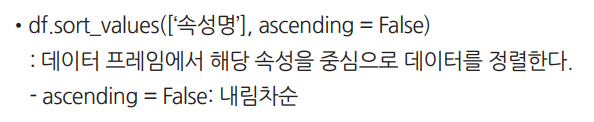

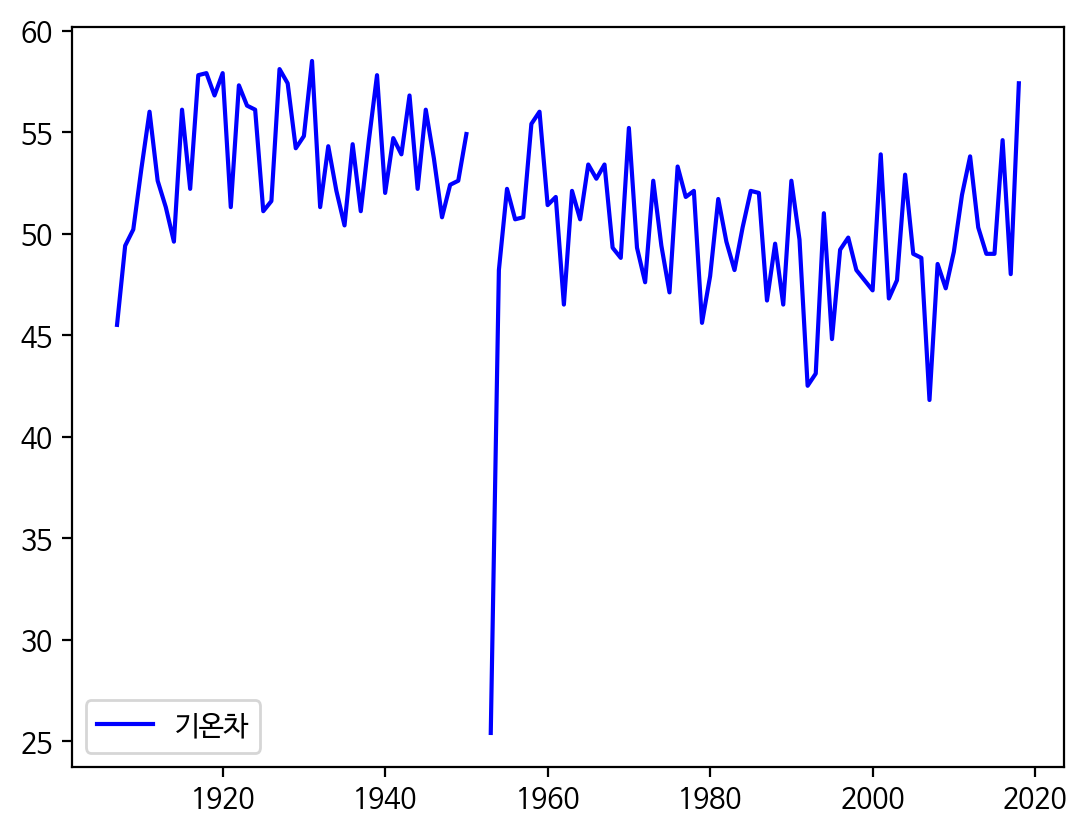

In [52]:
#연도별 최고기온과 최저기온의 기온차를 선그래프로 그리기
df2['기온차']=df2['최고기온']-df2['최저기온']
plt.plot(df['년'], df2['기온차'],'b',label='기온차')
plt.legend()
plt.show()

In [55]:
df4=df2.sort_values(['기온차'],ascending=False)
print(df4.head())

       년   지점  평균기온  최저기온  최고기온   기온차
24  1931  108  10.9 -22.5  36.0  58.5
20  1927  108  11.0 -23.1  35.0  58.1
13  1920  108  11.4 -22.3  35.6  57.9
11  1918  108  10.5 -21.8  36.1  57.9
32  1939  108  11.7 -19.6  38.2  57.8
